In [83]:
# 1 stocastic gradient descent

import warnings;

warnings.simplefilter('ignore')
import csv
import matplotlib.pyplot as plt
import numpy as np


def loadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]

    return inputs, outputs


def loadDataMoreInputs(fileName, inputVariabNames, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable1 = dataNames.index(inputVariabNames[0])
    selectedVariable2 = dataNames.index(inputVariabNames[1])
    inputs = [[float(data[i][selectedVariable1]), float(data[i][selectedVariable2])] for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]

    return inputs, outputs


def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()


def plotData(x1, y1, x2=None, y2=None, x3=None, y3=None, title=None):
    plt.plot(x1, y1, 'ro', label='train data')
    if (x2):
        plt.plot(x2, y2, 'b-', label='learnt model')
    if (x3):
        plt.plot(x3, y3, 'g^', label='test data')
    plt.title(title)
    plt.legend()
    plt.show()

def plot3Ddata(x1Train, x2Train, yTrain, x1Model=None, x2Model=None, yModel=None, x1Test=None, x2Test=None, yTest=None, title=None):
    from mpl_toolkits import mplot3d
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    if x1Train is not None and len(x1Train) > 0:
        ax.scatter(x1Train, x2Train, yTrain, c='r', marker='o', label='train data')
    if x1Model is not None and len(x1Model) > 0:
        ax.scatter(x1Model, x2Model, yModel, c='b', marker='_', label='learnt model')
    if x1Test is not None and len(x1Test) > 0:
        ax.scatter(x1Test, x2Test, yTest, c='g', marker='^', label='test data')
    plt.title(title)
    ax.set_xlabel("capita")
    ax.set_ylabel("freedom")
    ax.set_zlabel("happiness")
    ax.legend()
    plt.show()


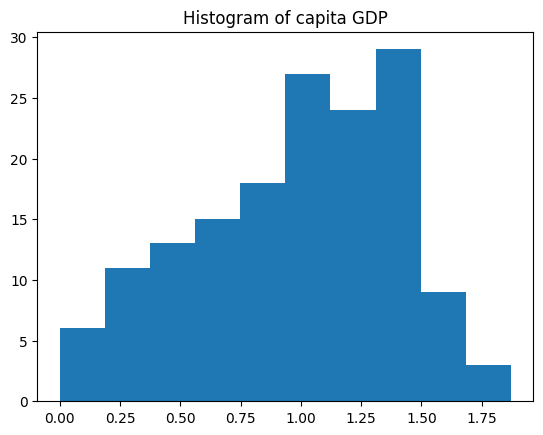

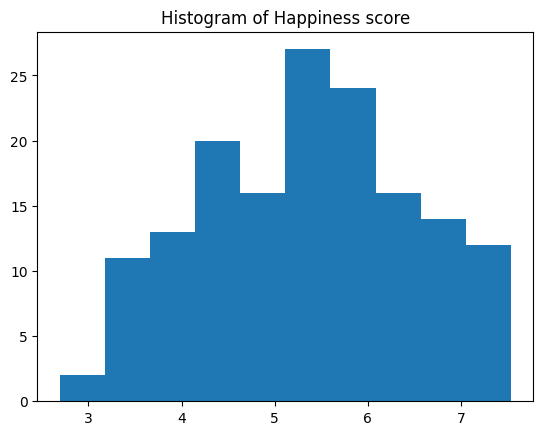

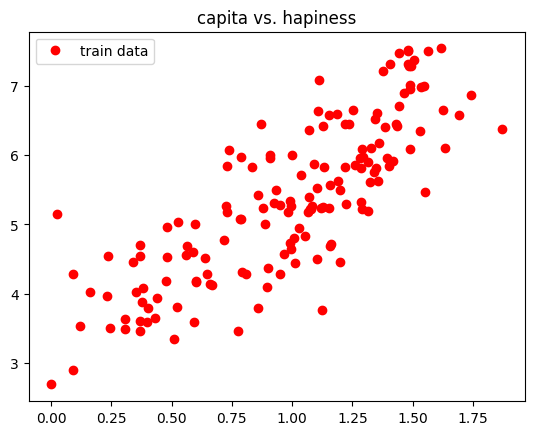

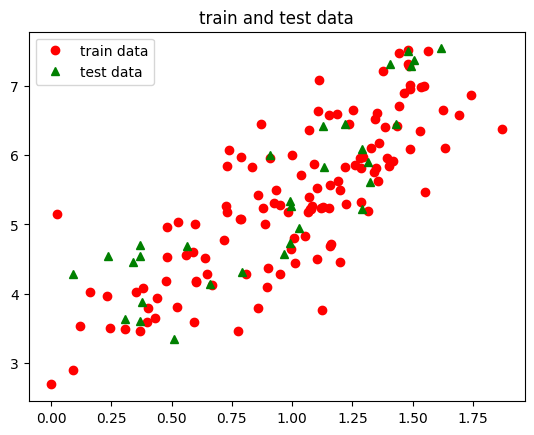

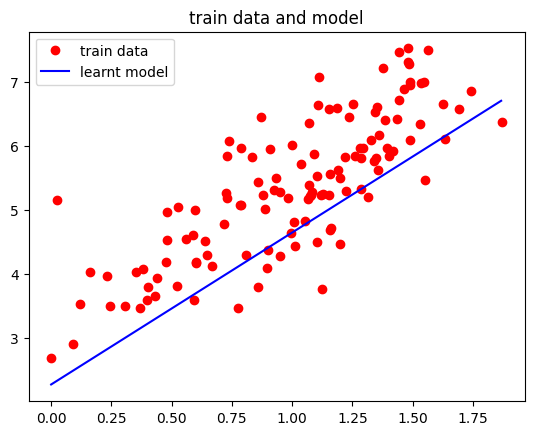

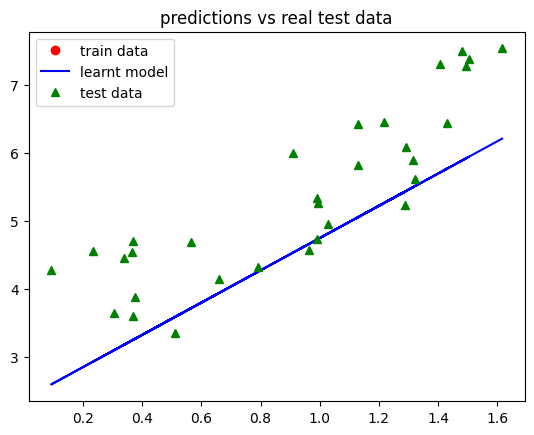

prediction error (manual):  1.016366392497045
prediction error (tool):  1.0163663924970447


In [84]:
from sklearn.metrics import mean_squared_error
from sklearn import linear_model
from SGD import MySGDRegression

def univariateRegression():
    import os

    crtDir = os.getcwd()
    filePath = os.path.join(crtDir, 'data', 'world-happiness-report-2017.csv')

    inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')

    plotDataHistogram(inputs, 'capita GDP')
    plotDataHistogram(outputs, 'Happiness score')

    # check the liniarity (to check that a linear relationship exists between the dependent variable (y = happiness) and the independent variable (x = capita).)
    plotData(inputs, outputs, [], [], [], [], 'capita vs. hapiness')

    # split data into training data (80%) and testing data (20%)
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
    testSample = [i for i in indexes if not i in trainSample]
    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]

    plotData(trainInputs, trainOutputs, [], [], testInputs, testOutputs, "train and test data")

    # training step
    xx = [[el] for el in trainInputs]

    ##using tool sklearn
    # regressor = linear_model.SGDRegressor(max_iter=10000)

    ##using tool sklearn batches
    # regressor=linear_model.SGDRegressor(max_iter=1000,tol=1e-3,learning_rate='constant',eta0=0.01)

    ##using my own code
    regressor = MySGDRegression()

    # fit for others
    # regressor.fit(xx, trainOutputs)

    ##using my own code batches mode
    regressor.fit(xx, trainOutputs,batch_mode=True)

    w0, w1 = regressor.intercept_, regressor.coef_[0]

    # plot the model
    noOfPoints = 1000
    xref = []
    val = min(trainInputs)
    step = (max(trainInputs) - min(trainInputs)) / noOfPoints
    for i in range(1, noOfPoints):
        xref.append(val)
        val += step
    yref = [w0 + w1 * el for el in xref]
    plotData(trainInputs, trainOutputs, xref, yref, [], [], title="train data and model")

    #makes predictions for test data
    # computedTestOutputs = [w0 + w1 * el for el in testInputs]
    #makes predictions for test data (by tool)
    computedTestOutputs = regressor.predict([[x] for x in testInputs])
    plotData([], [], testInputs, computedTestOutputs, testInputs, testOutputs, "predictions vs real test data")

    #compute the differences between the predictions and real outputs
    error = 0.0
    for t1, t2 in zip(computedTestOutputs, testOutputs):
        error += (t1 - t2) ** 2
    error = error / len(testOutputs)
    print("prediction error (manual): ", error)

    error = mean_squared_error(testOutputs, computedTestOutputs)
    print("prediction error (tool): ", error)


univariateRegression()

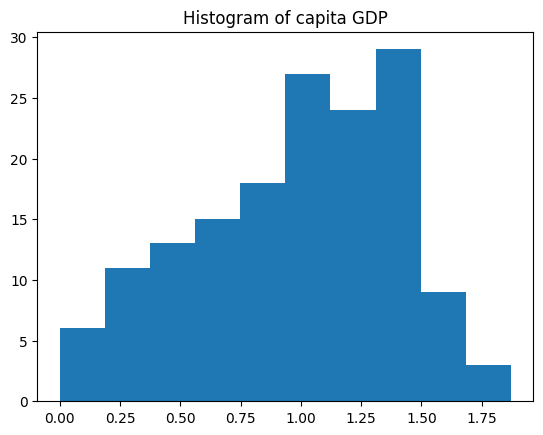

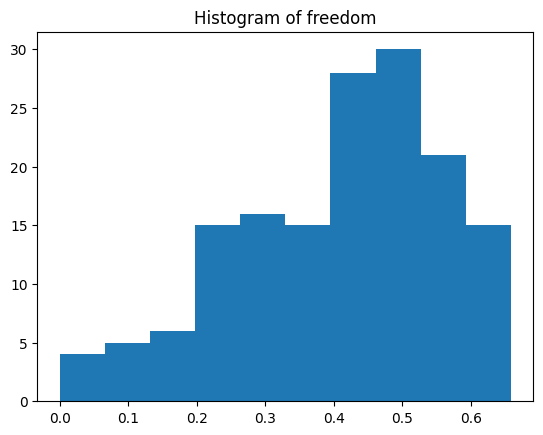

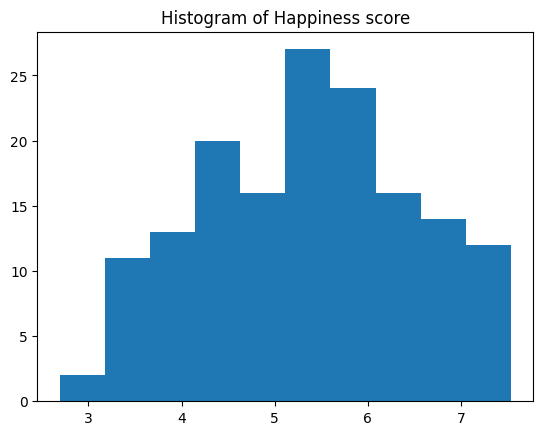

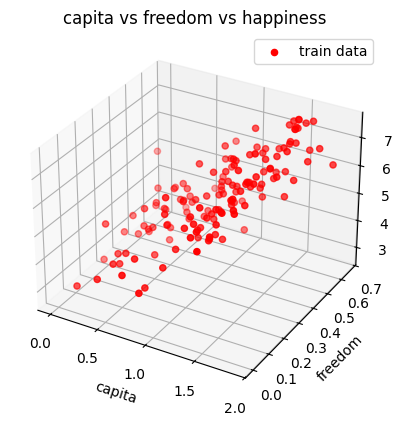

In [85]:
import os

# 1 gradient descent pt gdp si freedom

# problem hapiness = w0 + w1 * GDPcapita + w2 * freedom
# load data
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'data', 'world-happiness-report-2017.csv')

inputs, outputs = loadDataMoreInputs(filePath, ['Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score')

feature1 = [ex[0] for ex in inputs]
feature2 = [ex[1] for ex in inputs]

# plot the data histograms
plotDataHistogram(feature1, 'capita GDP')
plotDataHistogram(feature2, 'freedom')
plotDataHistogram(outputs, 'Happiness score')

# check the liniarity (to check that a linear relationship exists between the dependent variable (y = happiness) and the independent variables (x1 = capita, x2 = freedom).)
plot3Ddata(feature1, feature2, outputs, [], [], [], [], [], [], 'capita vs freedom vs happiness')

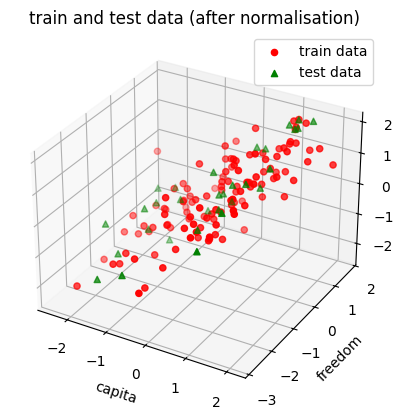

In [86]:
from sklearn.preprocessing import StandardScaler


def normalisation(trainData, testData):
    scaler = StandardScaler()
    if not isinstance(trainData[0], list):
        #encode each sample into a list
        trainData = [[d] for d in trainData]
        testData = [[d] for d in testData]

        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData)  # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data

        #decode from list to raw values
        normalisedTrainData = [el[0] for el in normalisedTrainData]
        normalisedTestData = [el[0] for el in normalisedTestData]
    else:
        scaler.fit(trainData)  #  fit only on training data
        normalisedTrainData = scaler.transform(trainData)  # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data
    return normalisedTrainData, normalisedTestData


np.random.seed(5)
indexes = [i for i in range(len(inputs))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
testSample = [i for i in indexes if not i in trainSample]

trainInputs = [inputs[i] for i in trainSample]
trainOutputs = [outputs[i] for i in trainSample]
testInputs = [inputs[i] for i in testSample]
testOutputs = [outputs[i] for i in testSample]

trainInputs, testInputs = normalisation(trainInputs, testInputs)
trainOutputs, testOutputs = normalisation(trainOutputs, testOutputs)

feature1train = [ex[0] for ex in trainInputs]
feature2train = [ex[1] for ex in trainInputs]

feature1test = [ex[0] for ex in testInputs]
feature2test = [ex[1] for ex in testInputs]

plot3Ddata(feature1train, feature2train, trainOutputs, [], [], [], feature1test, feature2test, testOutputs,
           "train and test data (after normalisation)")

In [87]:
from sklearn import linear_model
# # use sklearn regressor
# regressor = linear_model.SGDRegressor()

# # use sklearn regressor on batches
# regressor = linear_model.SGDRegressor(max_iter=1000,tol=1e-3,learning_rate='constant',eta0=0.01)

# using developed code
from SGD import MySGDRegression
# model initialisation
# regressor = MySGDRegression()

# fit for the rest
# regressor.fit(trainInputs, trainOutputs)

# model initialization using batches
regressor=MySGDRegression()
regressor.fit(trainInputs, trainOutputs,batch_mode=True)

#parameters of the liniar regressor
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]

if isinstance(w0, np.ndarray):
    w0 = w0[0]

print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x1 + ', w2, ' * x2' )

the learnt model: f(x) =  9.46684487074424e-17  +  0.46499214073179  * x1 +  0.2738364637432751  * x2


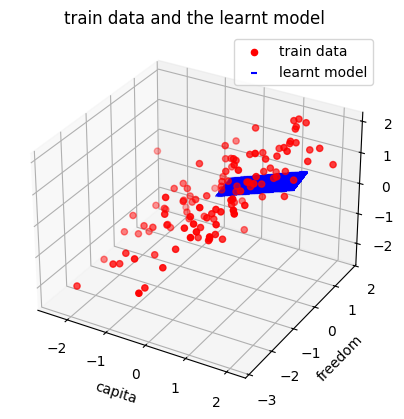

In [88]:
#numerical representation of the regressor model
noOfPoints = 50
xref1 = []
val = min(feature1)
step1 = (max(feature1) - min(feature1)) / noOfPoints
for _ in range(1, noOfPoints):
    for _ in range(1, noOfPoints):
        xref1.append(val)
    val += step1

xref2 = []
val = min(feature2)
step2 = (max(feature2) - min(feature2)) / noOfPoints
for _ in range(1, noOfPoints):
    aux = val
    for _ in range(1, noOfPoints):
        xref2.append(aux)
        aux += step2
yref = [w0 + w1 * el1 + w2 * el2 for el1, el2 in zip(xref1, xref2)]
plot3Ddata(feature1train, feature2train, trainOutputs, xref1, xref2, yref, [], [], [], 'train data and the learnt model')

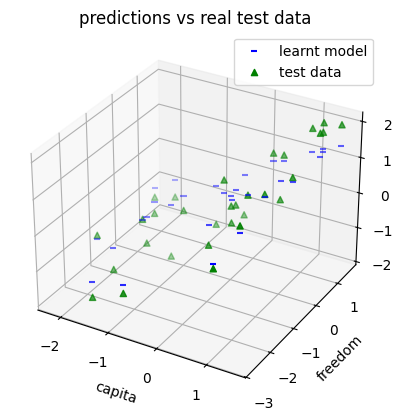

In [89]:
# use the trained model to predict new inputs

# makes predictions for test data
# computedTestOutputs = [w0 + w1 * el[0] + w2 * el[1] for el in testInputs]
# makes predictions for test data (by tool)
computedTestOutputs = regressor.predict(testInputs)

plot3Ddata([], [], [], feature1test, feature2test, computedTestOutputs, feature1test, feature2test, testOutputs, 'predictions vs real test data')

In [90]:
#compute the differences between the predictions and real outputs
error = 0.0
for t1, t2 in zip(computedTestOutputs, testOutputs):
    error += (t1 - t2) ** 2
error = error / len(testOutputs)
print('prediction error (manual): ', error)

from sklearn.metrics import mean_squared_error

error = mean_squared_error(testOutputs, computedTestOutputs)
print('prediction error (tool):   ', error)

prediction error (manual):  0.32837359503176267
prediction error (tool):    0.3283735950317628


In [91]:
# 2 clasificare tesuturi cancerigene

import numpy as np

def load_wdbc_data(filepath):
    X = []
    y = []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            label = 1 if parts[1] == 'M' else 0  # 1=malignant, 0=benign
            radius = float(parts[2])  # radius_mean
            texture = float(parts[3]) # texture_mean
            X.append([radius, texture])
            y.append(label)
    return np.array(X), np.array(y)

In [92]:
X, y = load_wdbc_data('data/wdbc.data')

np.random.seed(5)
indexes = [i for i in range(len(X))]
trainSample = np.random.choice(indexes, int(0.8 * len(X)), replace=False)
testSample = [i for i in indexes if i not in trainSample]

X_train = [list(x) for x in X[trainSample]]
y_train = y[trainSample]
X_test = [list(x) for x in X[testSample]]
y_test = y[testSample]

X_train, X_test = normalisation(X_train, X_test)

In [93]:
from sklearn.linear_model import SGDClassifier
from SGD import MySGDClassifier

## model initialization using tools
# clf=SGDClassifier(loss='log_loss')

# model initialization using my code
clf=MySGDClassifier(lr=0.01, epochs=1000)

clf.fit(X_train, y_train)

In [94]:
# predictions
y_pred= clf.predict(X_test)

In [95]:
from sklearn.metrics import accuracy_score

# metrics
correct = sum([1 for yt, yp in zip(y_test, y_pred) if yt == yp])
accuracy_manual = correct / len(y_test)
print("Manual accuracy:", accuracy_manual)

accuracy_tool = accuracy_score(y_test, y_pred)
print("Tool accuracy:", accuracy_tool)

Manual accuracy: 0.8070175438596491
Tool accuracy: 0.8070175438596491


In [96]:
# daca o leziune (dintr-o mamografie) caracterizata printr-o textura de valoare 10 si o raza de valoare 18 este leziune maligna sau benigna

new_sample = [[18, 10]]

scaler=StandardScaler()
scaler.fit(X_train) # deja normalizat

new_sample_normalized = scaler.transform(new_sample)

prediction = clf.predict(new_sample_normalized)
prob=clf.predict_proba(new_sample_normalized)[0]

if prediction[0] == 1:
    print("The lesion is predicted to be malignant with probability ", prob)
else:
    print("The lesion is predicted to be benign with probability ", prob)

The lesion is predicted to be malignant with probability  1.0


In [97]:
# 3 ce fel de floare preferi?

from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
X = iris.data # shape
y = iris.target # 0 - setosa, 1 - versicolor, 2 - virginica

np.random.seed(5)
indexes=[i for i in range(len(X))]
trainSample=np.random.choice(indexes, int(0.8 * len(X)), replace=False)
testSample=[i for i in indexes if i not in trainSample]

X_train_raw=[list(x) for x in X[trainSample]]
y_train=y[trainSample]
X_test=[list(x) for x in X[testSample]]
y_test=y[testSample]

X_train, X_test = normalisation(X_train_raw, X_test)

In [124]:
# model initialization using tools
clf=SGDClassifier(loss='log_loss')

# model initialization using my code
# clf=MySGDClassifier()

clf.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [125]:
# predictions
y_pred= clf.predict(X_test)

In [126]:
# Manual accuracy
correct = sum([1 for yt, yp in zip(y_test, y_pred) if yt == yp])
accuracy_manual = correct / len(y_test)
print("Manual accuracy:", accuracy_manual)

# Tool accuracy
from sklearn.metrics import accuracy_score
accuracy_tool = accuracy_score(y_test, y_pred)
print("Tool accuracy:", accuracy_tool)

Manual accuracy: 0.9333333333333333
Tool accuracy: 0.9333333333333333


In [111]:
# specia unei flori de iris care are sepala lunga de 5.35 cm si lata de 3.85 cm, iar petala lunga de 1.25 cm si lata de 0.4cm

new_sample = [[5.35, 3.85, 1.25, 0.4]]

scaler=StandardScaler()
scaler.fit(X_train_raw)


new_sample_normalized = scaler.transform(new_sample)

prediction = clf.predict(new_sample_normalized)
prob=clf.predict_proba(new_sample_normalized)[0]

if prediction[0] == 0:
    print("The iris is predicted to be setosa with probability ", prob)
elif prediction[0] == 1:
    print("The iris is predicted to be versicolor with probability ", prob)
else:
    print("The iris is predicted to be virginica with probability ", prob)

The iris is predicted to be setosa with probability  [9.99999921e-01 7.91563357e-08 7.13849048e-51]


In [102]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def k_fold_cross_validation_classifier(X, y, k=5, lr=0.01, epochs=1000, loss='log'):
    X = np.array(X)
    y = np.array(y)
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    fold_sizes = np.full(k, len(X) // k, dtype=int)
    fold_sizes[:len(X) % k] += 1
    current = 0
    accuracies = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        test_idx = indices[start:stop]
        train_idx = np.concatenate([indices[:start], indices[stop:]])
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
        # Normalize
        X_train_norm, X_test_norm = normalisation(X_train.tolist(), X_test.tolist())
        # Train classifier
        clf = MySGDClassifier(lr=lr, epochs=epochs, loss=loss)
        clf.fit(X_train_norm, y_train)
        y_pred = clf.predict(X_test_norm)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        current = stop
    avg_acc = np.mean(accuracies)
    print(f"{k}-fold cross-validation average accuracy (loss={loss}): {avg_acc:.4f}")
    print(f"Accuracies for each fold: {accuracies}")
    return avg_acc, accuracies

# Investigate different loss functions
X, y = load_wdbc_data('data/wdbc.data')
for loss in ['log', 'hinge', 'perceptron']:
    k_fold_cross_validation_classifier(X, y, k=5, lr=0.01, epochs=1000, loss=loss)

# Investigate effect of decision threshold
np.random.seed(5)
indexes = [i for i in range(len(X))]
trainSample = np.random.choice(indexes, int(0.8 * len(X)), replace=False)
testSample = [i for i in indexes if i not in trainSample]
X_train = [list(x) for x in X[trainSample]]
y_train = y[trainSample]
X_test = [list(x) for x in X[testSample]]
y_test = y[testSample]
X_train, X_test = normalisation(X_train, X_test)
clf = MySGDClassifier(lr=0.01, epochs=1000, loss='log')
clf.fit(X_train, y_train)
probs = clf.predict_proba(X_test)
thresholds = np.arange(0.1, 1.0, 0.1)
print("\nThreshold investigation:")
for thresh in thresholds:
    preds = np.array(probs >= thresh, dtype=int)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"Threshold: {thresh:.2f} | Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")


KeyboardInterrupt: 